In [1]:
## Libraries:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import torch
from torch import nn


In [2]:
## Data:
data = pd.read_csv("study_hours_grades.csv")

X = torch.tensor(data['study_hours'].values, dtype=torch.float32).unsqueeze(1) # Shape (100,) -> (100, 1)
y = torch.tensor(data['grade'].values, dtype=torch.float32).unsqueeze(1)   # Shape (100,) -> (100, 1)

print("-"*25)
print(X.shape)
print(X.ndim)
print(y.shape)
print(y.ndim)
print("-"*25)

-------------------------
torch.Size([50, 1])
2
torch.Size([50, 1])
2
-------------------------


In [3]:
## Split data as Train-Test:
train_split = int(len(X) * 0.8)
X_train, y_train = X[:train_split], y[:train_split] # 80% of the data for training.
X_test, y_test = X[train_split:], y[train_split:] # 20% of the data for testing.

print(X_train.shape, y_train.shape) # Shape of X_train and y_train variables.
print(X_test.shape, y_test.shape) # Shape of X_test and y_test variables.

torch.Size([40, 1]) torch.Size([40, 1])
torch.Size([10, 1]) torch.Size([10, 1])


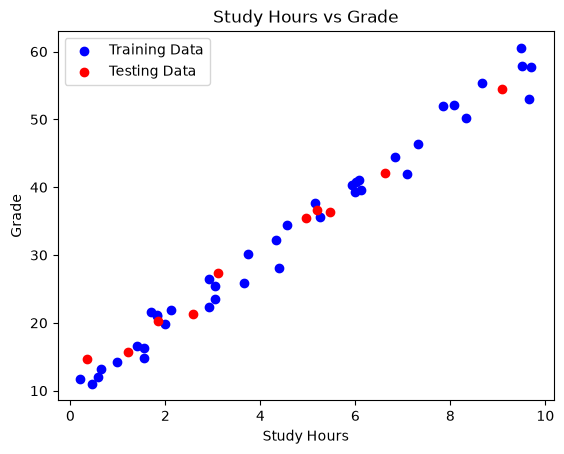

In [4]:
## Draw a scatter plot of the data:
plt.scatter(X_train, y_train, c='blue', label='Training Data')
plt.scatter(X_test, y_test, c='red', label='Testing Data')
plt.xlabel('Study Hours')
plt.ylabel('Grade')
plt.title('Study Hours vs Grade')
plt.legend()
plt.show()


In [5]:
class LinearRegressionModel(nn.Module):
    def __init__(self):
        super().__init__()

        self.linear_layer = nn.Linear(in_features=1, out_features=1) # We need to add one hidden layer to the model. 

    def forward(self, x: torch.Tensor) -> torch.Tensor: # Forward pass.
        return self.linear_layer(x)

## Initialize the model:
torch.manual_seed(42)
model = LinearRegressionModel()
# model = torch.compile(model)

print(list(model.parameters()))
print(list(model.state_dict()))

[Parameter containing:
tensor([[0.7645]], requires_grad=True), Parameter containing:
tensor([0.8300], requires_grad=True)]
['linear_layer.weight', 'linear_layer.bias']


In [6]:
## Loss function and optimizer:
loss_fn = nn.MSELoss()
optimizer = torch.optim.SGD(params=model.parameters(), lr=0.001)  

## Train model:
epoch_count = []
train_loss_values = []
test_loss_values = []

In [8]:
for epoch in range(200):
    model.train()
    
    # 1. Forward pass
    y_preds = model(X_train)
    
    # 2. Calculate loss
    loss = loss_fn(y_preds, y_train)
    
    # 3. Zero gradients
    optimizer.zero_grad()
    
    # 4. Backpropagation
    loss.backward()
    
    # 5. Update parameters
    optimizer.step()

    model.eval()
    with torch.inference_mode():    
        test_pred = model(X_test)
        test_loss = loss_fn(test_pred, y_test)

        if epoch % 10 == 0:
            print(f"Epoch: {epoch}, Loss: {loss.item()}, Test Loss: {test_loss.item()}")
            epoch_count.append(epoch)
            train_loss_values.append(loss.item())
            test_loss_values.append(test_loss.item())

Epoch: 0, Loss: 21.14592170715332, Test Loss: 26.1770076751709
Epoch: 10, Loss: 20.945573806762695, Test Loss: 25.909276962280273
Epoch: 20, Loss: 20.749412536621094, Test Loss: 25.65923500061035
Epoch: 30, Loss: 20.556028366088867, Test Loss: 25.419431686401367
Epoch: 40, Loss: 20.364986419677734, Test Loss: 25.18610954284668
Epoch: 50, Loss: 20.176151275634766, Test Loss: 24.957317352294922
Epoch: 60, Loss: 19.989456176757812, Test Loss: 24.732013702392578
Epoch: 70, Loss: 19.804872512817383, Test Loss: 24.50965118408203
Epoch: 80, Loss: 19.62236785888672, Test Loss: 24.289928436279297
Epoch: 90, Loss: 19.441925048828125, Test Loss: 24.07265281677246
Epoch: 100, Loss: 19.263525009155273, Test Loss: 23.857728958129883
Epoch: 110, Loss: 19.08713150024414, Test Loss: 23.64509391784668
Epoch: 120, Loss: 18.912729263305664, Test Loss: 23.4346866607666
Epoch: 130, Loss: 18.740291595458984, Test Loss: 23.226478576660156
Epoch: 140, Loss: 18.569805145263672, Test Loss: 23.020442962646484
Epo

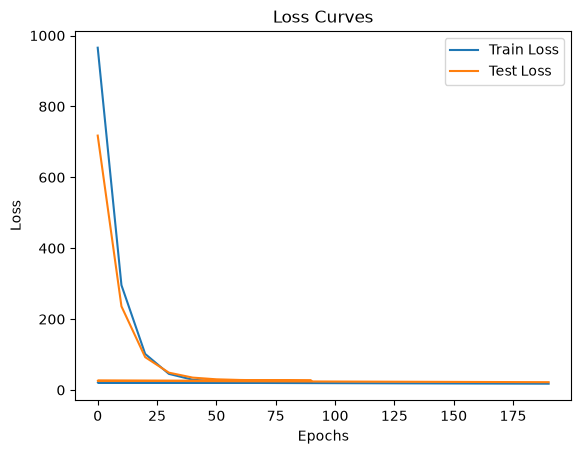

-------------------------
OrderedDict({'linear_layer.weight': tensor([[6.0941]]), 'linear_layer.bias': tensor([2.9844])})
-------------------------


In [10]:
## Plot Loss Curves:
plt.plot(epoch_count, train_loss_values, label="Train Loss")
plt.plot(epoch_count, test_loss_values, label="Test Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Loss Curves")
plt.legend()
plt.show()  
    
print("-"*25)
print(model.state_dict())
print("-"*25)

tensor([[1.2204],
        [4.9518],
        [0.3439],
        [9.0932],
        [2.5878],
        [6.6252],
        [3.1171],
        [5.2007],
        [5.4671],
        [1.8485]])
tensor([[10.4216],
        [33.1611],
        [ 5.0801],
        [58.3995],
        [18.7548],
        [43.3593],
        [21.9805],
        [34.6780],
        [36.3016],
        [14.2497]])

-------------------------


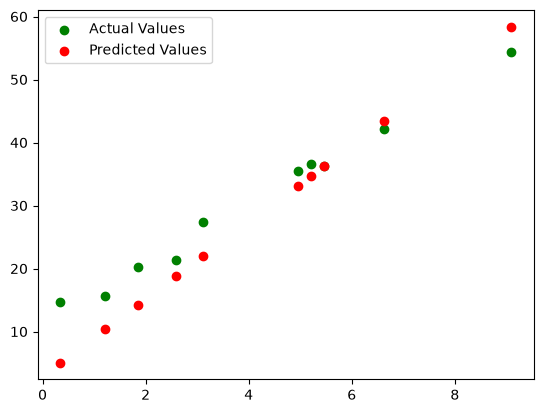

In [11]:
## Evaluate the model results:
model.eval()
with torch.inference_mode():
    y_preds = model(X_test)

print(X_test)
print(y_preds)

print("\n" + "-"*25)
plt.scatter(X_test, y_test, c='green', label='Actual Values')
plt.scatter(X_test, y_preds, c='red', label='Predicted Values')
plt.legend()
plt.show()  